In [228]:
from brick2221.analysis.analysis_setup import basepath

Set DATE-AVG to '2022-08-28T03:05:32.473' from MJD-AVG.
Set DATE-END to '2022-08-28T03:34:03.557' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -20.661125 from OBSGEO-[XYZ].
Set OBSGEO-H to 1526408297.850 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


For module merged catalog crowdsource_nsky0_merged_photometry_tables_merged.fits, mod date is 2024-07-12 21:04:29
For module merged-reproject catalog crowdsource_nsky0_merged-reproject_photometry_tables_merged.fits, mod date is 2024-07-10 08:27:09


In [191]:
import importlib as imp
import icemodels
imp.reload(icemodels.core)
imp.reload(icemodels)
from icemodels.core import (absorbed_spectrum, absorbed_spectrum_Gaussians, convsum,
                            optical_constants_cache_dir,
                            fluxes_in_filters, load_molecule, load_molecule_ocdb, atmo_model, molecule_data, read_ocdb_file)

# Load tables

In [236]:
cotbs = {}
for fn in glob.glob(f"{optical_constants_cache_dir}/*_CO:*") + glob.glob(f"{optical_constants_cache_dir}/*_CO *"):
    try:
        tb = read_ocdb_file(fn)
        basename = os.path.basename(os.path.splitext(fn)[0])
        spl = basename.split("_")
        idnum = int(spl[0])
        cotbs[idnum] = tb
        #tb.meta['idnum'] = idnum
        #tb.meta['molecule'] = spl[1]
        #tb.meta['temperature'] = spl[-2]
        #tb.meta['author'] = spl[-1]
    except Exception as ex:
        print(fn, spl)
        continue
cotbs.keys()

/red/adamginsburg/repos/icemodels/icemodels/data/105_CO:OCS (20:1)_30K_Hudgins.txt ['100', 'CO:CH4 (20:1)', '20K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/104_CO:OCS (20:1)_25K_Hudgins.txt ['41', 'CO:N2:H2O (5:5:1)', '12K', 'Elsila']
/red/adamginsburg/repos/icemodels/icemodels/data/102_CO:OCS (20:1)_10K_Hudgins.txt ['101', 'CO:CH4 (20:1)', '25K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/102_CO:OCS_(20:1)_10K_Hudgins.txt ['101', 'CO:CH4', '(20:1)', '25K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/103_CO:OCS_(20:1)_20K_Hudgins.txt ['101', 'CO:CH4', '(20:1)', '25K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/105_CO:OCS_(20:1)_30K_Hudgins.txt ['101', 'CO:CH4', '(20:1)', '25K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/103_CO:OCS (20:1)_20K_Hudgins.txt ['101', 'CO:CH4', '(20:1)', '25K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/104_CO:OCS_(20:1)_25K_Hudgins.txt ['100', 'CO:CH4', '(2

dict_keys([99, 41, 100, 98, 36, 101, 85, 35, 1, 63, 64, 34, 43, 269])

In [237]:
co2tbs = {}
for fn in glob.glob(f"{optical_constants_cache_dir}/*_CO2:*") + glob.glob(f"{optical_constants_cache_dir}/*_CO2 *"):
    try:
        tb = read_ocdb_file(fn)
        basename = os.path.basename(os.path.splitext(fn)[0])
        spl = basename.split("_")
        idnum = int(spl[0])
        co2tbs[idnum] = tb
        #tb.meta['idnum'] = idnum
        #tb.meta['molecule'] = spl[1]
        #tb.meta['temperature'] = spl[-2]
        #tb.meta['author'] = spl[-1]
    except Exception as ex:
        print(fn, spl)
        continue
co2tbs.keys()

/red/adamginsburg/repos/icemodels/icemodels/data/90_CO2:CH4 (20:1)_10K_Hudgins.txt ['96', 'CO2:OCS', '(20:1)', '30K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/91_CO2:CH4 (20:1)_20K_Hudgins.txt ['95', 'CO2:OCS', '(20:1)', '10K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/93_CO2:CH4_(20:1)_50K_Hudgins.txt ['95', 'CO2:OCS', '(20:1)', '10K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/94_CO2:CH4_(20:1)_70K_Hudgins.txt ['96', 'CO2:OCS (20:1)', '30K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/91_CO2:CH4_(20:1)_20K_Hudgins.txt ['96', 'CO2:OCS (20:1)', '30K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/94_CO2:CH4 (20:1)_70K_Hudgins.txt ['96', 'CO2:OCS (20:1)', '30K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/92_CO2:CH4 (20:1)_30K_Hudgins.txt ['96', 'CO2:OCS (20:1)', '30K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/90_CO2:CH4_(20:1)_10K_Hudgins.txt ['97', 'CO2:OCS', '(20:1)'

dict_keys([96, 46, 40, 95, 97, 87, 56, 2, 32, 86, 55, 89, 88, 33])

In [238]:
h2otbs = {}
for fn in glob.glob(f"{optical_constants_cache_dir}/*_H2O:*") + glob.glob(f"{optical_constants_cache_dir}/*_H2O *"):
    try:
        tb = read_ocdb_file(fn)
        basename = os.path.basename(os.path.splitext(fn)[0])
        spl = basename.split("_")
        idnum = int(spl[0])
        h2otbs[idnum] = tb
        #tb.meta['idnum'] = idnum
        #tb.meta['molecule'] = spl[1]
        #tb.meta['temperature'] = spl[-2]
        #tb.meta['author'] = spl[-1]
    except Exception as ex:
        print(fn, spl)
        continue
h2otbs.keys()

/red/adamginsburg/repos/icemodels/icemodels/data/76_H2O:He:CH4:N2:CO2_(0.66:0.16:0.066:0.065:0.049)_400K_He.txt ['267', 'H2O:NH3 (4:1)', '24K', 'Mukai']
/red/adamginsburg/repos/icemodels/icemodels/data/75_H2O:He:CH4:CO2:N2:H2 (0.56:0.147:0.11:0.1:0.064:0.019)_300K_He.txt ['120', 'H2O:CH3OH:CO:NH3 (100:50:1:1)', '120K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/76_H2O:He:CH4:N2:CO2 (0.66:0.16:0.066:0.065:0.049)_400K_He.txt ['132', 'H2O:OCS (2:1)', '120K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/75_H2O:He:CH4:CO2:N2:H2_(0.56:0.147:0.11:0.1:0.064:0.019)_300K_He.txt ['134', 'H2O:OCS', '(2:1)', '40K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/200_H2O:C2H6 (6:1)_300K_Khare.txt ['129', 'H2O:CH4', '(20:1)', '80K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/200_H2O:C2H6_(6:1)_300K_Khare.txt ['132', 'H2O:OCS', '(2:1)', '120K', 'Hudgins']
/red/adamginsburg/repos/icemodels/icemodels/data/298_H2O (1)_243K_Zhang.txt ['123', 'H2

dict_keys([121, 123, 267, 116, 124, 136, 128, 138, 129, 265, 133, 137, 118, 115, 120, 127, 135, 130, 131, 132, 122, 139, 119, 37, 125, 140, 117, 126, 39, 114, 113, 266, 134, 112, 107, 271, 227, 14, 109, 9, 4, 270, 111, 10, 110, 7, 201, 108, 5, 11, 12, 273, 106, 13, 8, 272])

In [269]:
for mol, tbs in {'H2O': h2otbs, 'CO': cotbs, 'CO2': co2tbs}.items():
    for tb in tbs.values():
        tb['k'] = tb['k₁']

{key: tb.colnames for key, tb in tbs.items()}

## Plot CO absorbance profiles

In [199]:
import pylab as pl

In [200]:
from astropy import units as u
import numpy as np

In [201]:
palumbo = load_molecule('co')

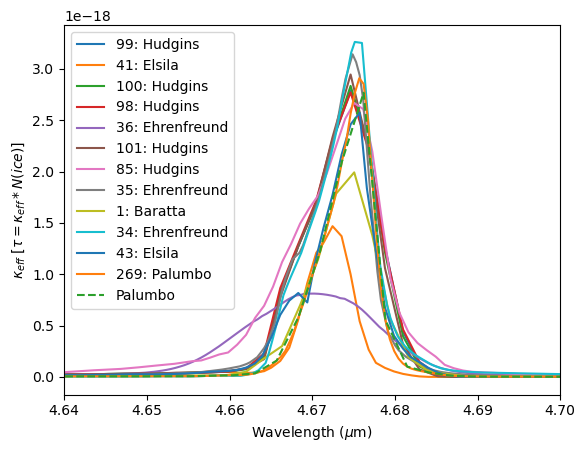

In [202]:
for key, tb in cotbs.items():
    if key in (64, 63):
        # bad - temporary
        continue
    pl.plot(tb['Wavelength'], 
            ((tb['k₁'] * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (28*u.Da)))).to(u.cm**2),
            label=f'{key}: {tb.meta["author"]}')
pl.plot(palumbo['Wavelength'],
        (palumbo['k']* palumbo['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (28*u.Da))).to(u.cm**2),
        linestyle='--',
        label='Palumbo')
pl.legend(loc='best');
pl.xlim(4.64, 4.70);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");

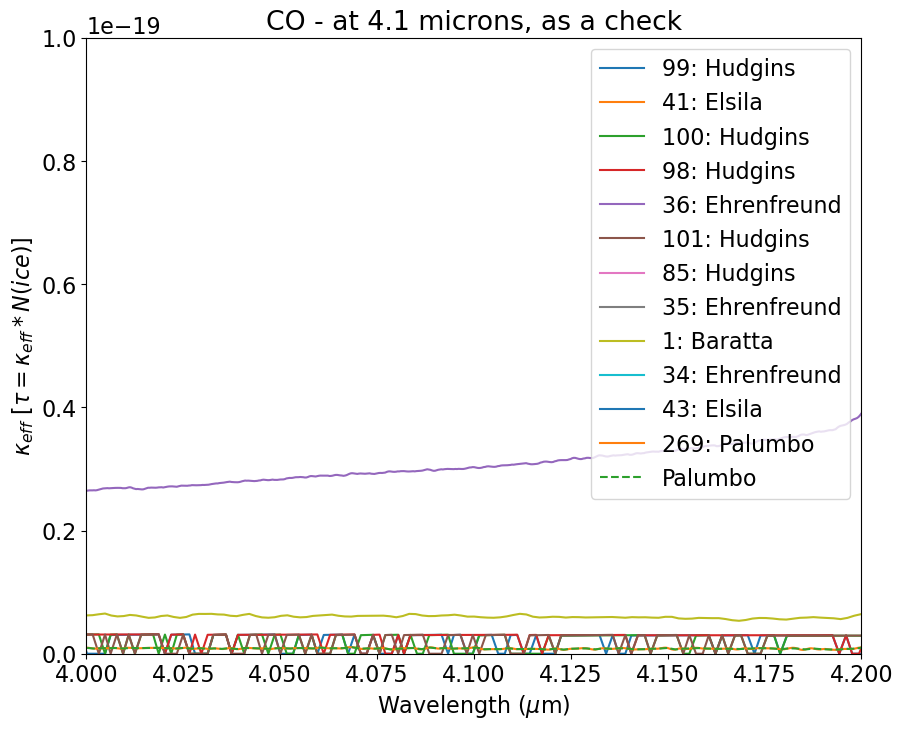

In [266]:
for key, tb in cotbs.items():
    if key in (64, 63):
        # bad - temporary
        continue
    pl.plot(tb['Wavelength'], 
            ((tb['k₁'] * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (28*u.Da)))).to(u.cm**2),
            label=f'{key}: {tb.meta["author"]}')
pl.plot(palumbo['Wavelength'],
        (palumbo['k']* palumbo['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (28*u.Da))).to(u.cm**2),
        linestyle='--',
        label='Palumbo')
pl.legend(loc='best');
pl.xlim(4.00, 4.20);
pl.ylim(0, 1e-19)
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");
pl.title("CO - at 4.1 microns, as a check");

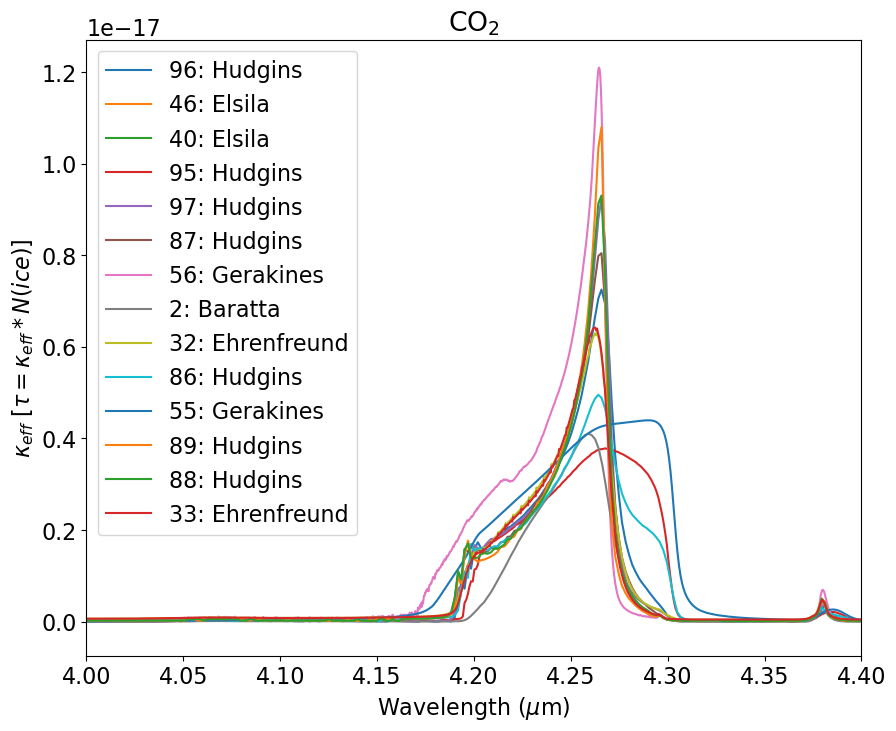

In [256]:
for key, tb in co2tbs.items():
    if key in (64, 63):
        # bad - temporary
        continue
    pl.plot(tb['Wavelength'], 
            ((tb['k₁'] * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (44*u.Da)))).to(u.cm**2),
            label=f'{key}: {tb.meta["author"]}')
pl.legend(loc='best');
pl.xlim(4.0, 4.40);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");
pl.title("CO$_2$");

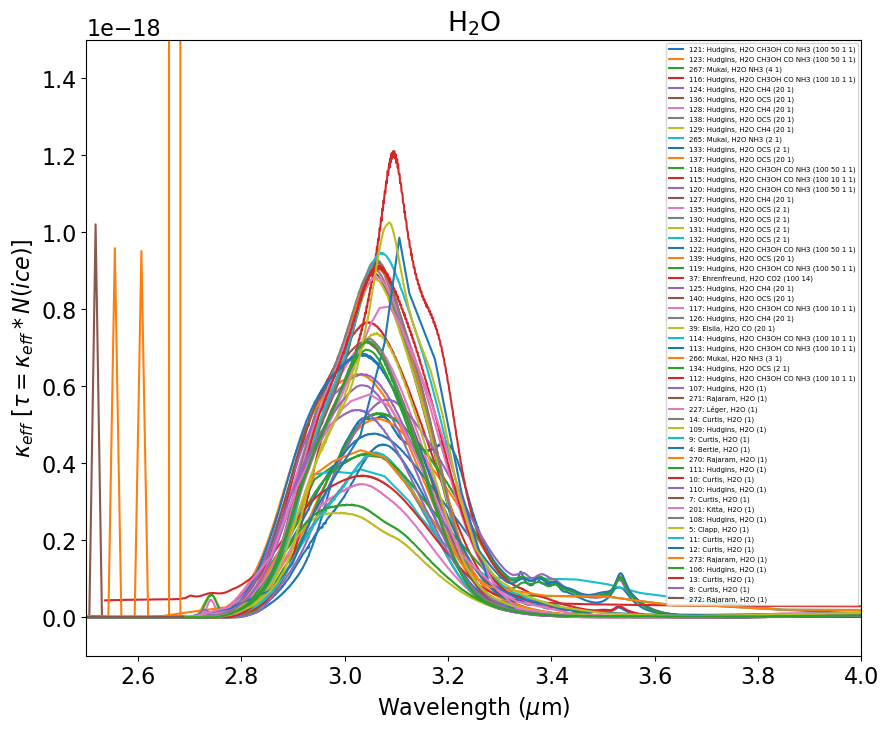

In [255]:
for key, tb in h2otbs.items():
    if key in (64, 63):
        # bad - temporary
        continue
    pl.plot(tb['Wavelength'], 
            ((tb['k₁'] * tb['Wavelength'].to(u.cm**-1, u.spectral()) * 4 * np.pi / (1*u.g/u.cm**3 / (18*u.Da)))).to(u.cm**2),
            label=f'{key}: {tb.meta["author"]}, {tb.meta["composition"]}')
pl.legend(loc='best', fontsize=5);
pl.xlim(2.50, 4.00);
pl.xlabel("Wavelength ($\\mu$m)")
pl.ylabel("$\\kappa_{eff}$ [$\\tau = \\kappa_{eff} * N(ice)$]");
pl.title("H$_2$O");
pl.ylim(-1e-19, 1.5e-18);

# Make absorbance -> N tables

In [209]:
import icemodels
imp.reload(icemodels.core)
imp.reload(icemodels)
from icemodels import absorbed_spectrum, absorbed_spectrum_Gaussians, convsum, fluxes_in_filters, load_molecule, load_molecule_ocdb, atmo_model, molecule_data

In [210]:
from astroquery.svo_fps import SvoFps

In [211]:
jfilts = SvoFps.get_filter_list('JWST')
jfilts.add_index('filterID')

In [212]:
#filterid = 'JWST/NIRCam.F466N'
#xarr = np.linspace(filter_data.loc[filterid]['WavelengthMin'] * u.AA,
#                   filter_data.loc[filterid]['WavelengthMax'] * u.AA,
#                   1000)
xarr = np.linspace(3.1*u.um, 4.9*u.um, 10000)
phx4000 = atmo_model(4000, xarr=xarr)

In [213]:
tb.meta

OrderedDict([('density', <Quantity 1. g / cm3>),
             ('reference', 'Palumbo et al. (2006)'),
             ('doi', 'doi https //doi.org/10.1039/B509279E '),
             ('composition', 'CO (1)'),
             ('temperature', '15K'),
             ('ocdb page', 'https //ocdb.smce.nasa.gov/dataset/269'),
             ('author', 'Palumbo'),
             ('molecule', 'CO')])

In [269]:
for mol, tbs in {'H2O': h2otbs, 'CO': cotbs, 'CO2': co2tbs}.items():
    for tb in tbs.values():
        tb['k'] = tb['k₁']

In [270]:
from astropy.table import Table

In [271]:
xarr = phx4000['nu'].quantity.to(u.um, u.spectral())
cols = np.geomspace(1e15, 1e22, 25)

for mol, tbs in {'H2O': h2otbs, 'CO': cotbs, 'CO2': co2tbs}.items():
    dmag_rows = []
    
    for key, consts in tbs.items():
        dmags410 = []
        dmags466 = []
        dmags444 = []
        dmags356 = []
        dmags405 = []
    
        molecule = tb.meta['molecule'].split()[0].lower()
    
        print(molecule, key)
        #print(f"  column,   mag410,  mag410*,  mag466n, mag466n*, dmag410, dmag466")
        for col in cols:
            spec = absorbed_spectrum(col*u.cm**-2, consts, molecular_weight=molecule_data[molecule]['molwt'],
                                      spectrum=phx4000['fnu'].quantity,
                                      xarr=xarr,
                                     )
            cmd_x = ('JWST/NIRCam.F410M', 'JWST/NIRCam.F466N', 'JWST/NIRCam.F356W', 'JWST/NIRCam.F444W',  'JWST/NIRCam.F405N')
            flxd_ref = fluxes_in_filters(xarr, phx4000['fnu'].quantity)
            flxd = fluxes_in_filters(xarr, spec)
            mags_x_star = (-2.5*np.log10(flxd_ref[cmd_x[0]] / u.Quantity(jfilts.loc[cmd_x[0]]['ZeroPoint'], u.Jy)),
                           -2.5*np.log10(flxd_ref[cmd_x[1]] / u.Quantity(jfilts.loc[cmd_x[1]]['ZeroPoint'], u.Jy)),
                           -2.5*np.log10(flxd_ref[cmd_x[2]] / u.Quantity(jfilts.loc[cmd_x[2]]['ZeroPoint'], u.Jy)),
                           -2.5*np.log10(flxd_ref[cmd_x[3]] / u.Quantity(jfilts.loc[cmd_x[3]]['ZeroPoint'], u.Jy)),
                           -2.5*np.log10(flxd_ref[cmd_x[4]] / u.Quantity(jfilts.loc[cmd_x[4]]['ZeroPoint'], u.Jy)),
                          )
            mags_x = (-2.5*np.log10(flxd[cmd_x[0]] / u.Quantity(jfilts.loc[cmd_x[0]]['ZeroPoint'], u.Jy)),
                      -2.5*np.log10(flxd[cmd_x[1]] / u.Quantity(jfilts.loc[cmd_x[1]]['ZeroPoint'], u.Jy)),
                      -2.5*np.log10(flxd[cmd_x[2]] / u.Quantity(jfilts.loc[cmd_x[2]]['ZeroPoint'], u.Jy)),
                      -2.5*np.log10(flxd[cmd_x[3]] / u.Quantity(jfilts.loc[cmd_x[3]]['ZeroPoint'], u.Jy)),
                      -2.5*np.log10(flxd[cmd_x[4]] / u.Quantity(jfilts.loc[cmd_x[4]]['ZeroPoint'], u.Jy)),
                     )
            dmags405.append(mags_x[4]-mags_x_star[4])
            dmags444.append(mags_x[3]-mags_x_star[3])
            dmags356.append(mags_x[2]-mags_x_star[2])
            dmags466.append(mags_x[1]-mags_x_star[1])
            dmags410.append(mags_x[0]-mags_x_star[0])
            # why would f410m change at all?
            #print(f"{col:8.1g}, {mags_x[0]:8.1f}, {mags_x_star[0]:8.1f}, {mags_x[1]:8.1f}, {mags_x_star[1]:8.1f}, {dmags410[-1]:8.1f}, {dmags466[-1]:8.1f}")
            dmag_rows.append({'molecule': molecule, 'mol_id': key, 'column': col, 'F356W': dmags356[-1], 'F410M': dmags410[-1],
                              'F444W': dmags444[-1], 'F466N': dmags466[-1], 'F405N': dmags405[-1]})
    dmag_tbl = Table(dmag_rows)
    dmag_tbl.write(f'{basepath}/tables/{mol}_ice_absorption_tables.ecsv', overwrite=True)
    dmag_tbl.add_index('mol_id')
    dmag_tbl

co2 121
co2 123
co2 267
co2 116
co2 124
co2 136
co2 128
co2 138
co2 129
co2 265
co2 133
co2 137
co2 118
co2 115
co2 120
co2 127
co2 135
co2 130
co2 131
co2 132
co2 122
co2 139
co2 119
co2 37
co2 125
co2 140
co2 117
co2 126
co2 39
co2 114
co2 113
co2 266
co2 134
co2 112
co2 107
co2 271
co2 227
co2 14


/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


co2 109
co2 9
co2 4
co2 270
co2 111
co2 10
co2 110
co2 7
co2 201
co2 108
co2 5
co2 11
co2 12
co2 273
co2 106
co2 13
co2 8
co2 272
co2 99
co2 41
co2 100
co2 98
co2 36
co2 101
co2 85
co2 35
co2 1
co2 63


/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


co2 64
co2 34
co2 43
co2 269
co2 96
co2 46
co2 40
co2 95
co2 97
co2 87
co2 56
co2 2
co2 32
co2 86
co2 55
co2 89
co2 88
co2 33


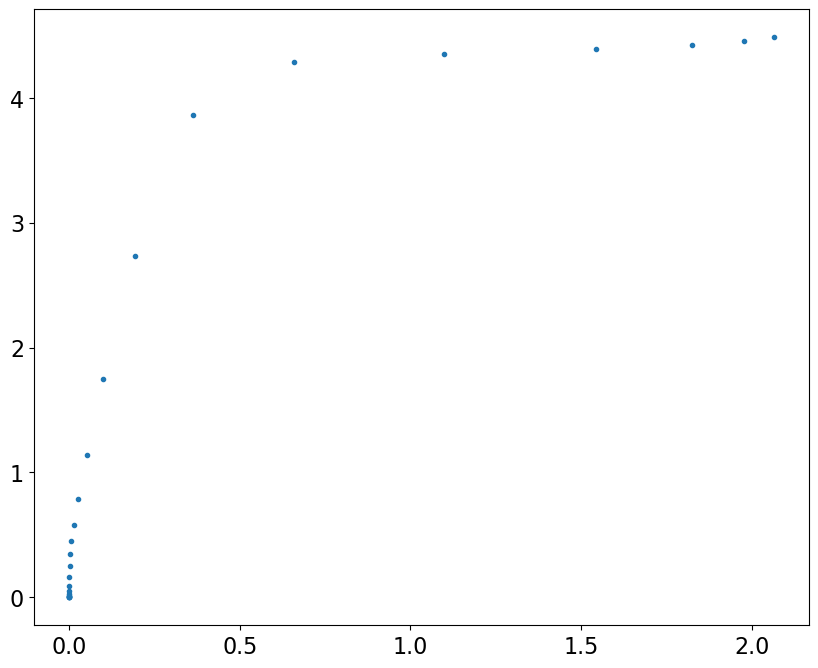

In [265]:
pl.plot(dmag_tbl.loc[99]['F410M'], dmag_tbl.loc[99]['F466N'], '.');

64
1
98
99
100
36
101
35
34
41
43
269
85
63


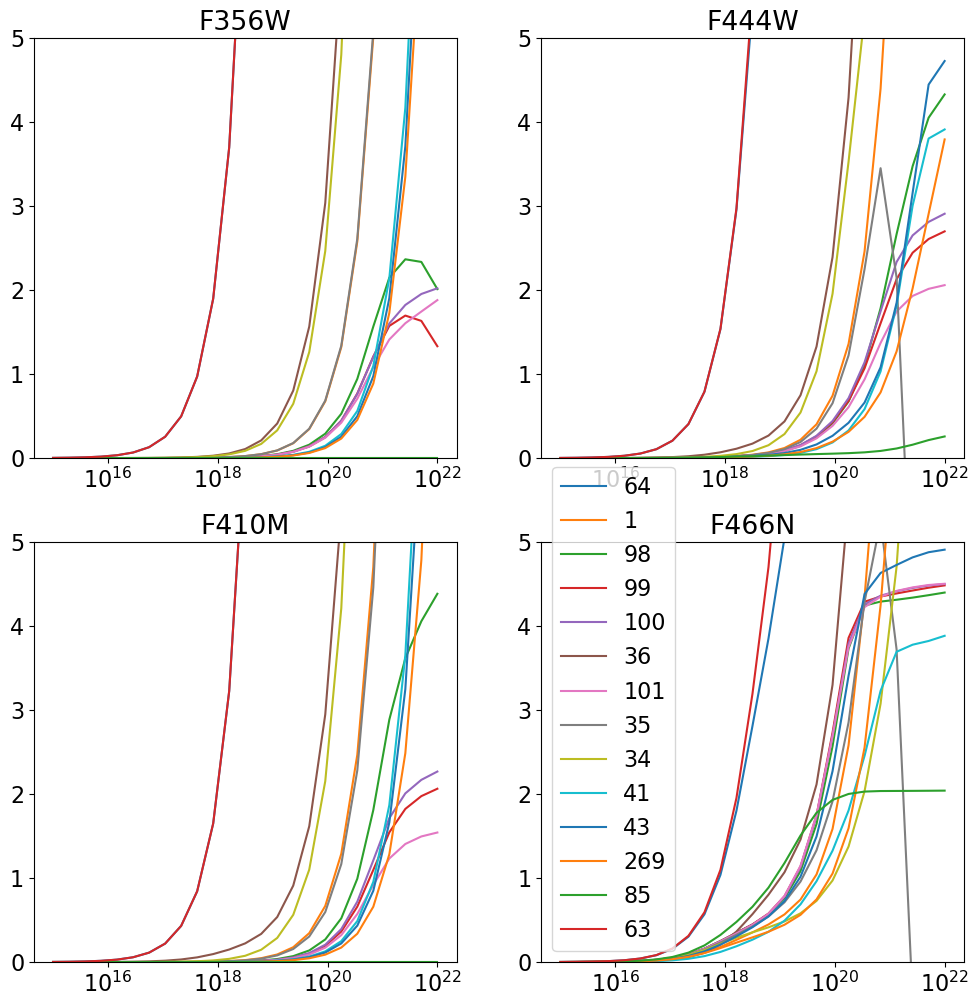

In [263]:
dmag_tbl.add_index('mol_id')
fig = pl.figure(figsize=(12,12))
for mol_id in set(dmag_tbl['mol_id']):
    print(mol_id)
    cols = dmag_tbl.loc[mol_id]['column']
    for ii, filtername in enumerate(['F356W', 'F444W', 'F410M', 'F466N',]):
        pl.subplot(2, 2, ii+1).semilogx(cols, dmag_tbl.loc[mol_id][filtername], label=mol_id)
        pl.ylim(0,5);
        pl.title(filtername)
pl.legend(loc='best');